# 01 — Getting started with pyEIT

*Investigation of Reconstruction Algorithms and Current Injection Patterns in EIT*
Project Seminar Virtual Acoustics · supervisor M.Sc. Jacob P. Thönes

---

Electrical impedance tomography pushes a small current through a pair of electrodes on the edge of
a tank and measures the voltages on the other electrodes. From those voltages it tries to work out
what the conductivity looks like inside.

This notebook is the warm-up: build a mesh, run one simulated measurement, and get one picture out.
The settings used here are reused by all the other notebooks.

**One thing worth knowing up front.** Everything here is *difference imaging*: we simulate the tank
twice, once empty and once with an object in it, and reconstruct the *change* between the two sets
of voltages. That is much easier than working out the conductivity from scratch, and it is what all
three pyEIT methods are built for.

In [1]:
import os, sys, time, warnings
from pathlib import Path

# Find pyEIT: either installed, or via the PYEIT_PATH environment variable.
try:
    import pyeit
except ImportError:
    for folder in filter(None, [os.environ.get("PYEIT_PATH"), "../pyEIT", "./pyEIT"]):
        if (Path(folder) / "pyeit").is_dir():
            sys.path.insert(0, str(Path(folder).resolve())); break
    import pyeit

sys.path.insert(0, str(Path.cwd()))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import eit_helpers as eit

eit.use_project_style()
figures = Path("figures"); figures.mkdir(exist_ok=True)
tables = Path("results"); tables.mkdir(exist_ok=True)

print(f"{eit.NUMBER_OF_ELECTRODES} electrodes, background conductivity "
      f"{eit.BACKGROUND_CONDUCTIVITY}, images {eit.IMAGE_SIZE}x{eit.IMAGE_SIZE}")

16 electrodes, background conductivity 1.0, images 64x64


## The mesh

pyEIT builds a triangular mesh of the tank and puts the electrodes evenly around the edge.

We make **two** meshes: a fine one to simulate the measurements, and a coarser one to reconstruct
on. Using the same mesh for both would let the reconstruction cheat, because the errors would
cancel out exactly and everything would look better than it really is.

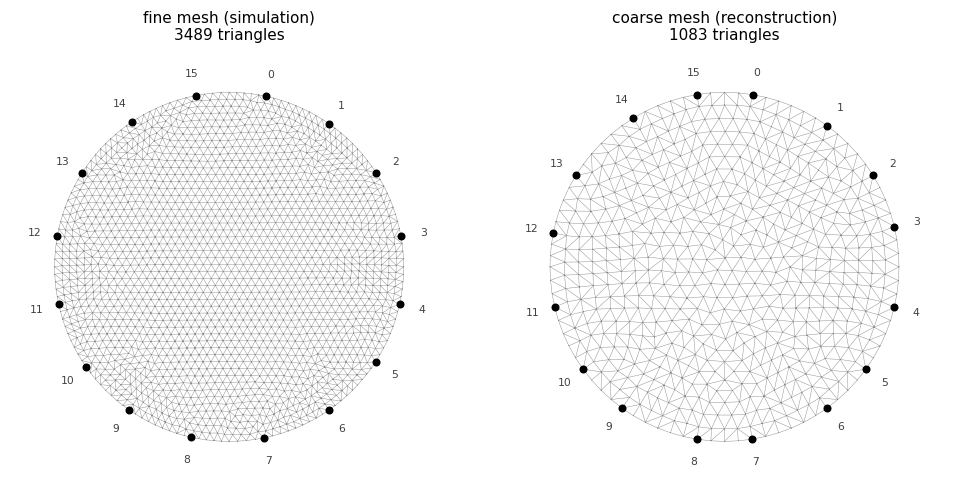

In [2]:
fine_mesh, coarse_mesh = eit.build_meshes()

figure, axes = plt.subplots(1, 2, figsize=(9, 4.4), constrained_layout=True)
for axis, tank_mesh, label in zip(axes, (fine_mesh, coarse_mesh),
                                  ("fine mesh (simulation)", "coarse mesh (reconstruction)")):
    axis.triplot(tank_mesh.node[:, 0], tank_mesh.node[:, 1], tank_mesh.element,
                 lw=0.3, color="0.55")
    eit.mark_electrodes(axis, tank_mesh)
    axis.set_aspect("equal"); axis.set_xticks([]); axis.set_yticks([])
    axis.set_xlim(-1.25, 1.25); axis.set_ylim(-1.25, 1.25)
    for edge in axis.spines.values():
        edge.set_visible(False)
    axis.set_title(f"{label}\n{tank_mesh.n_elems} triangles")
figure.savefig(figures / "01_meshes.png")
plt.show()

## What the current actually does

Before reconstructing anything, it helps to see where the current goes. Below is the voltage inside
the tank for two different pairs of driving electrodes.

Injecting between **neighbouring** electrodes keeps almost all the current in a thin sliver near the
edge — the middle of the tank barely notices. Injecting between **opposite** electrodes sends
current straight across. This one picture explains a lot of what shows up later: objects in the
middle are hard to see, and how hard depends on which pattern you use.

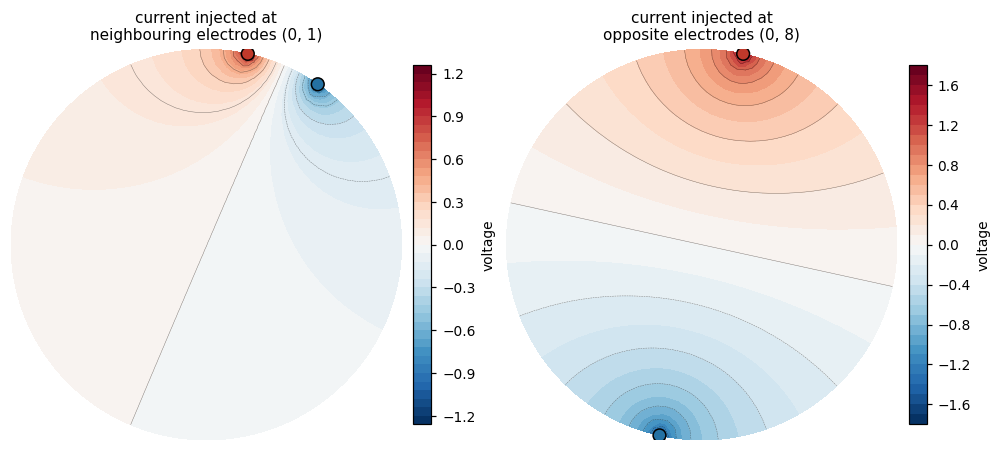

In [3]:
from pyeit.eit.fem import Forward

field_solver = Forward(fine_mesh)

figure, axes = plt.subplots(1, 2, figsize=(9, 4.2), constrained_layout=True)
for axis, (label, electrode_pair) in zip(
        axes, {"neighbouring electrodes (0, 1)": np.array([0, 1]),
               "opposite electrodes (0, 8)": np.array([0, 8])}.items()):
    voltage = np.real(field_solver.solve(ex_line=electrode_pair))
    voltage = voltage - voltage.mean()
    drawn = axis.tricontourf(fine_mesh.node[:, 0], fine_mesh.node[:, 1],
                             fine_mesh.element, voltage, levels=41, cmap="RdBu_r",
                             vmin=-np.abs(voltage).max(), vmax=np.abs(voltage).max())
    axis.tricontour(fine_mesh.node[:, 0], fine_mesh.node[:, 1], fine_mesh.element,
                    voltage, levels=21, colors="k", linewidths=0.3, alpha=0.5)
    driving = fine_mesh.node[fine_mesh.el_pos[electrode_pair]]
    axis.scatter(driving[:, 0], driving[:, 1], s=70,
                 facecolor=["#c0392b", "#2471a3"], edgecolor="k", zorder=8)
    axis.set_aspect("equal"); axis.set_xticks([]); axis.set_yticks([])
    for edge in axis.spines.values():
        edge.set_visible(False)
    axis.set_title(f"current injected at\n{label}")
    figure.colorbar(drawn, ax=axis, fraction=0.046, pad=0.03, label="voltage")
figure.savefig(figures / "01_current_paths.png")
plt.show()

## One simulated measurement

Now put a single object in the tank — a circle of radius 0.15 at position (0.5, 0), twice as
conductive as its surroundings — and look at the voltages.

16 current injections, 208 voltage readings per frame


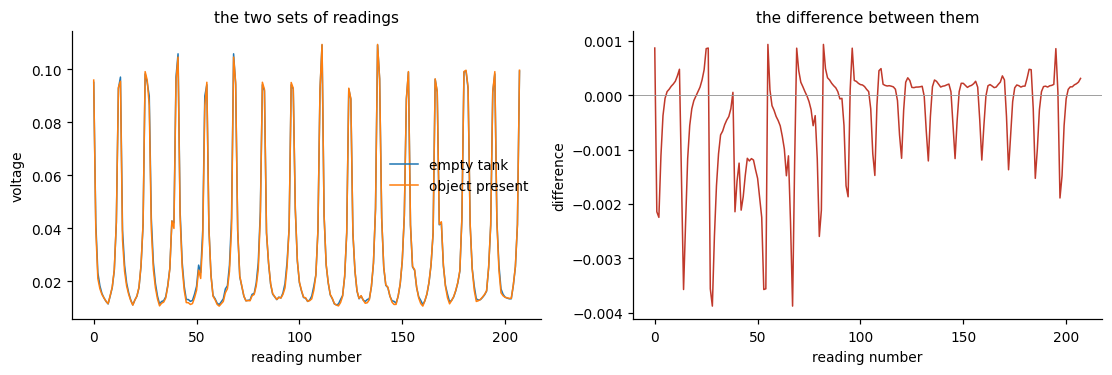


the object changes the voltages by about 2.0 %


In [4]:
measurement_setup = eit.build_measurement_setup("adjacent")
print(f"{measurement_setup.n_exc} current injections, "
      f"{measurement_setup.n_meas} voltage readings per frame")

one_object = [{"centre": [0.5, 0.0], "radius": 0.15, "conductivity": 2.0}]
tank_with_object = eit.add_objects(fine_mesh, one_object)

background_voltages, object_voltages = eit.simulate_measurements(
    fine_mesh, tank_with_object, measurement_setup)
voltage_change = np.real(object_voltages - background_voltages)

figure, axes = plt.subplots(1, 2, figsize=(10, 3.3), constrained_layout=True)
axes[0].plot(np.real(background_voltages), lw=1.0, label="empty tank")
axes[0].plot(np.real(object_voltages), lw=1.0, label="object present")
axes[0].set_xlabel("reading number"); axes[0].set_ylabel("voltage")
axes[0].set_title("the two sets of readings"); axes[0].legend()

axes[1].plot(voltage_change, lw=1.0, color="#c0392b")
axes[1].axhline(0, lw=0.6, color="0.6")
axes[1].set_xlabel("reading number"); axes[1].set_ylabel("difference")
axes[1].set_title("the difference between them")
figure.savefig(figures / "01_voltages.png")
plt.show()

print(f"\nthe object changes the voltages by about "
      f"{100 * np.abs(voltage_change).mean() / np.abs(background_voltages).mean():.1f} %")

The two voltage curves look almost identical — the object only shifts them by a couple of percent.
That small difference is the entire signal EIT has to work with, which is a good reminder of why
the images come out blurry.

## First reconstruction

Feed those two sets of voltages into one of pyEIT's methods and see what comes back.

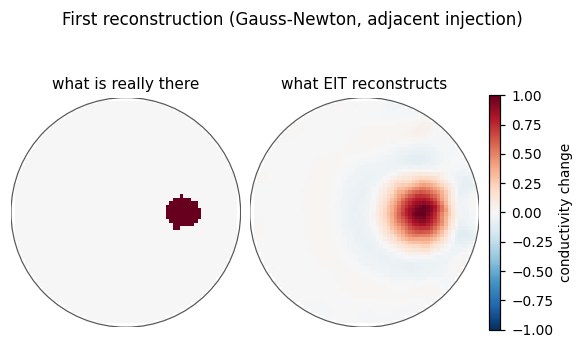

,value,meaning
size,0.285,how big the reconstructed blob is (0.15 = corr...
position_error,0.012,how far the blob sits from where the object re...
shape_error,0.024,how far from circular the blob is (0 = perfect...
ringing,0.248,how much false opposite-coloured halo surround...
brightness,0.046,average pixel value of the image


In [5]:
truth = eit.true_picture(fine_mesh, tank_with_object)
result = eit.reconstruct_image("gauss_newton", coarse_mesh, measurement_setup,
                               object_voltages, background_voltages)

figure, _ = eit.show_images([truth, result.image],
                            ["what is really there", "what EIT reconstructs"],
                            heading="First reconstruction (Gauss-Newton, adjacent injection)")
figure.savefig(figures / "01_first_reconstruction.png")
plt.show()

scores = eit.score_image(truth, result.image)
pd.DataFrame({"value": pd.Series(scores).round(3),
              "meaning": pd.Series(eit.SCORE_MEANINGS)})

The object is in roughly the right place, but it has turned into a soft blob about twice its real
size. That is normal for EIT and not a bug in the settings — it is the best this kind of
measurement can do.

## How the images are scored

The three methods return their answers in three different formats, so `eit_helpers` redraws all of
them onto the same 64×64 picture before comparing anything. The scores come from pyEIT's own
image-quality functions:

| score | what it means | best value |
|---|---|---|
| size | how big the blob is | 0.15 here (the real radius) |
| position error | how far the blob is from the real object | 0 |
| shape error | how far from circular the blob is | 0 |
| ringing | false opposite-coloured halo around the blob | 0 |

## Settings used everywhere else

In [6]:
settings = pd.DataFrame([
    ("tank",                "circle of radius 1"),
    ("electrodes",          f"{eit.NUMBER_OF_ELECTRODES}, evenly spaced"),
    ("background",          f"conductivity {eit.BACKGROUND_CONDUCTIVITY}"),
    ("simulation mesh",     f"{fine_mesh.n_elems} triangles"),
    ("reconstruction mesh", f"{coarse_mesh.n_elems} triangles"),
    ("standard object",     "circle, radius 0.15, conductivity 2.0"),
    ("injection patterns",  ", ".join(f"{name} (gap {gap})"
                                      for name, gap in eit.INJECTION_PATTERNS.items())),
    ("methods",             "back-projection, Gauss-Newton, GREIT"),
    ("image size",          f"{eit.IMAGE_SIZE} x {eit.IMAGE_SIZE}"),
    ("random seed",         f"{eit.RANDOM_SEED} (results repeat exactly)"),
], columns=["setting", "value"])
settings.to_csv(tables / "01_settings.csv", index=False)
pd.set_option("display.max_colwidth", None)
settings

,setting,value
0,tank,circle of radius 1
1,electrodes,"16, evenly spaced"
2,background,conductivity 1.0
3,simulation mesh,3489 triangles
4,reconstruction mesh,1083 triangles
5,standard object,"circle, radius 0.15, conductivity 2.0"
6,injection patterns,"adjacent (gap 1), opposite (gap 8), skip_4 (gap 5)"
7,methods,"back-projection, Gauss-Newton, GREIT"
8,image size,64 x 64
9,random seed,2026 (results repeat exactly)


---

## What I took away from this notebook

- pyEIT makes the mesh, the measurement plan and the reconstruction fairly painless — most of the
  work is deciding what to simulate.
- Injecting between neighbouring electrodes hardly reaches the middle of the tank; injecting
  between opposite electrodes does. That difference comes back in notebook 05.
- A solid object only changes the measured voltages by a couple of percent.
- Even with perfect, noise-free data the reconstruction is a blob about twice the real size.

**Next:** [02 — comparing the three methods](02_reconstruction_methods.ipynb)